## Analyze the hydrostatic stiffness for a single flap

In [1]:
import numpy as np
import os
import xarray as xr
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pygmsh
import capytaine as cpt
from scipy.io import loadmat

import wecopttool as wot

import logging 
logging.getLogger().setLevel(logging.INFO)

INFO:capytaine.io.meshio:Stored 348 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_0"), lid_mesh=None, dofs={}, center_of_mass=[ 0.    0.   -0.42], name="flap1").
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="flap1").rotation_center = (0, 0, -0.59)
INFO:capytaine.bodies.bodies:Clipping flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_0 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.


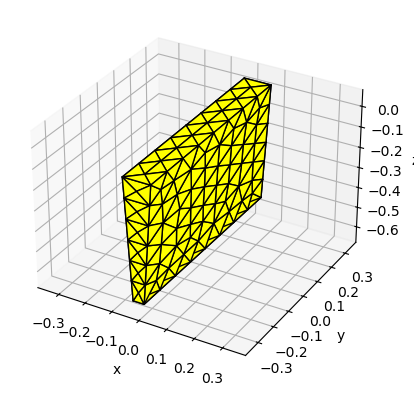

In [2]:

flapThicknessBottom = 0.04
flapThicknessTop    = 0.1
flapCenterDistanceApart = 1.44
flapWidth   = 0.76
flapHeight = 0.58
flapDraft  = 0.59 # 0.53 is based on matching impedance, 0.59 for fully submerged
cgHeightAboveHinge = 0.17
flap1CG     = [0, 0, -flapDraft+cgHeightAboveHinge] # from water surface/origin\


with pygmsh.geo.Geometry() as geom:
    flap1 = geom.add_polygon(
            [[-flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft],
            [-flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft]],mesh_size=0.1)
    geom.extrude(flap1,[0,flapWidth,0])
    flap1Mesh = geom.generate_mesh()

# define the floating body
flap1 = cpt.FloatingBody(mesh=flap1Mesh, name=f'flap1', center_of_mass=flap1CG)

#axis = cpt.Axis(vector=(0, 1, 0), point=(0, 0, -flapDraft))
#flap1.add_rotation_dof(name="Pitch_about_hinge", axis=axis)
#flap1.rotation_center = (0, 0, -flapDraft)

# try specifying cg at hinge so Capytaine calculates hydrostatics around hinge
flap1.center_of_mass = flap1CG
flap1.rotation_center = (0, 0, -flapDraft)
flap1.add_rotation_dof(name='Pitch')

flap_mass = 23.1
flap_inertia = 1.19
flap1.mass = flap_mass
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([flap_inertia]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(flap1.dofs),
                                    'radiating_dof': list(flap1.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
flap1.inertia_matrix = rigid_inertia_matrix_xr
flap1.hydrostatic_stiffness = flap1.immersed_part().compute_hydrostatic_stiffness()

flap1.show_matplotlib()
#flap1.show()

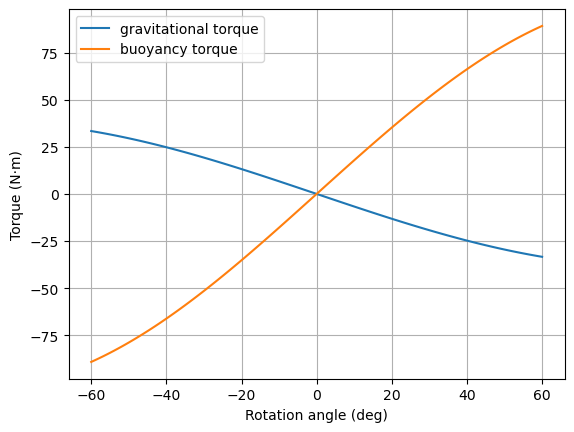

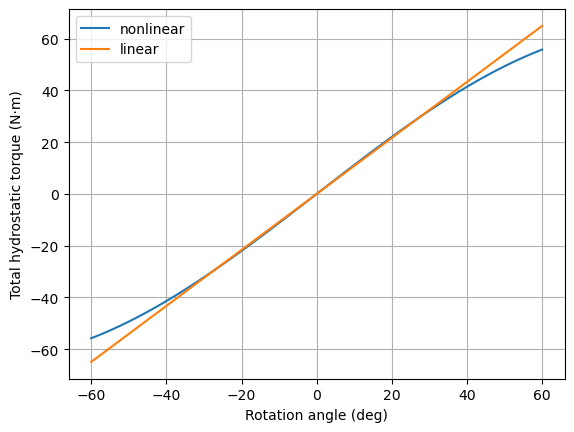

In [3]:
# manually calculate hydrostatic force
g = 9.81
rho = 1025

# hydrostatic force is based on difference between gravity force and buoyancy force
flap_rotation_vec = np.linspace(-60, 60, 121)

force_gravity = g*flap1.mass
force_buoyancy = rho*g*flap1.volume

torque_gravity = []
torque_buoyancy = []
total_torque = []
linear_torque = []

for flap_rotation in flap_rotation_vec:   

    gravity_moment_arm = cgHeightAboveHinge*np.sin(np.deg2rad(flap_rotation))
    buoyancy_moment_arm = (flapDraft+flap1.center_of_buoyancy[2])*np.sin(np.deg2rad(flap_rotation))

    torque_gravity.append(-force_gravity*gravity_moment_arm)
    torque_buoyancy.append(force_buoyancy*buoyancy_moment_arm)

    total_torque.append(torque_gravity[-1] + torque_buoyancy[-1])

    # linear stiffness 
    linear_torque.append(np.squeeze(flap1.hydrostatic_stiffness*np.deg2rad(flap_rotation)))

plt.figure()
plt.plot(flap_rotation_vec, torque_gravity, label='gravitational torque')
plt.plot(flap_rotation_vec, torque_buoyancy, label='buoyancy torque')
plt.xlabel("Rotation angle (deg)")
plt.ylabel("Torque (N·m)")
plt.grid(True)
plt.legend()

plt.figure()
plt.plot(flap_rotation_vec, total_torque, label='nonlinear')
plt.plot(flap_rotation_vec, linear_torque, label='linear')
plt.xlabel("Rotation angle (deg)")
plt.ylabel("Total hydrostatic torque (N·m)")
plt.grid(True)
plt.legend()

INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="flap1").rotation_center = (0, 0, -0.59)
INFO:capytaine.bodies.bodies:Clipping flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_0 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.


INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="flap1").rotation_center = (0, 0, -0.59)
INFO:capytaine.bodies.bodies:Clipping flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_0 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="flap1").rotation_center = (0, 0, -0.59)
INFO:capytaine.bodies.bodies:Clipping flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_0 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="flap1").rotation_center = (0, 0, -0.59)
INFO:capytaine.bodies.bodies:Clipping flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0.

Text(0, 0.5, 'Hydrostatic stiffness (Nm/rad)')

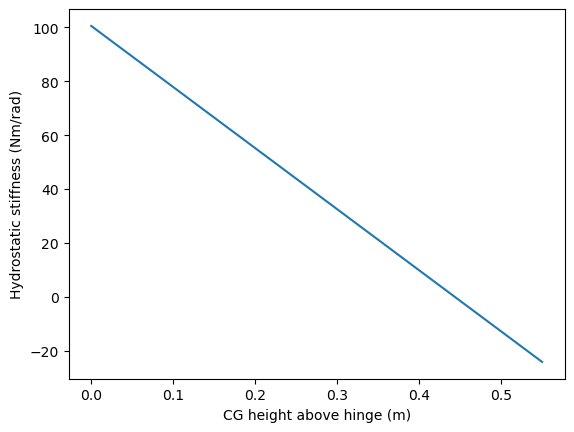

In [ ]:
# run through different cg values
cgHeightAboveHinge_vec = np.linspace(0,0.55,12)

stiffness = []

for cgHeightAboveHingeNew in cgHeightAboveHinge_vec:
    flap1.center_of_mass = [0, 0, -flapDraft+cgHeightAboveHingeNew]
    flap1.rotation_center = (0, 0, -flapDraft)
    flap1.add_rotation_dof(name='Pitch')

    flap1.mass = flap_mass
    flap1.hydrostatic_stiffness = flap1.immersed_part().compute_hydrostatic_stiffness()
    stiffness.append(np.squeeze(flap1.hydrostatic_stiffness))

plt.figure()
plt.plot(cgHeightAboveHinge_vec, stiffness)
plt.xlabel('CG height above hinge (m)')
plt.ylabel('Hydrostatic stiffness (Nm/rad)')


INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="flap1").rotation_center = (0, 0, -0.59)
INFO:capytaine.bodies.bodies:Clipping flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_0 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="flap1").rotation_center = (0, 0, -0.59)
INFO:capytaine.bodies.bodies:Clipping flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_0 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="flap1").rotation_center = (0, 0, -0.59)
INFO:capytaine.bodies.bodies:Clipping flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0.

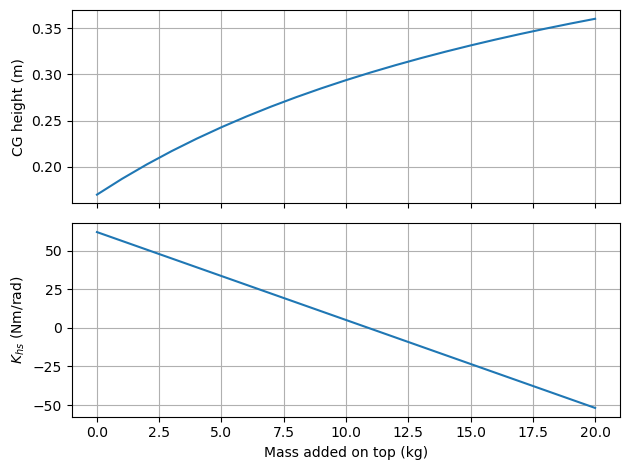

In [11]:
# run through different cg and mass values
mass_on_top_vec = np.linspace(0,20,21)

cgHeightAboveHingeNew = np.zeros(len(mass_on_top_vec))
stiffness = []

for mass_ind, mass_on_top in enumerate(mass_on_top_vec):

    cgHeightAboveHingeNew[mass_ind] = (cgHeightAboveHinge*flap_mass + mass_on_top*flapHeight)/(flap_mass + mass_on_top)

    flap1.center_of_mass = [0, 0, -flapDraft+cgHeightAboveHingeNew[mass_ind]]
    flap1.rotation_center = (0, 0, -flapDraft)
    flap1.add_rotation_dof(name='Pitch')

    flap1.mass = flap_mass + mass_on_top
    flap1.hydrostatic_stiffness = flap1.immersed_part().compute_hydrostatic_stiffness()
    stiffness.append(np.squeeze(flap1.hydrostatic_stiffness))

fig, ax = plt.subplots(2, 1, sharex=True)

ax[0].plot(mass_on_top_vec, cgHeightAboveHingeNew)
ax[0].set_ylabel('CG height (m)')
ax[0].grid(True)

ax[1].plot(mass_on_top_vec, stiffness)
ax[1].set_xlabel('Mass added on top (kg)')
ax[1].set_ylabel(r'$K_{hs}$ (Nm/rad)')
ax[1].grid(True)

plt.tight_layout()